# Notebook 08 — Final Model Evaluation

## Objective

The objective of this notebook is to perform the final evaluation of the optimized Random Forest model.

The notebook includes:

- Final performance evaluation
- Confusion Matrix
- ROC Curve
- Feature Importance Analysis
- Model Interpretation
- Project Conclusion
- Future Work

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv("../data/processed/engineered_data.csv")

print("Dataset Loaded Successfully")

print(df.shape)

df.head()

In [ ]:
X = df.drop("readmitted", axis=1)

y = df["readmitted"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape :", X_train.shape)
print("Testing Shape :", X_test.shape)

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=2,
    min_samples_leaf=2,
    random_state=42
)

model.fit(X_train, y_train)

print("Final Tuned Random Forest Model Trained Successfully.")

In [6]:
y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Accuracy  : 0.6602
Precision : 0.6511
Recall    : 0.5658
F1 Score  : 0.6055


In [7]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      0.74      0.70     10973
           1       0.65      0.57      0.61      9381

    accuracy                           0.66     20354
   macro avg       0.66      0.65      0.65     20354
weighted avg       0.66      0.66      0.66     20354



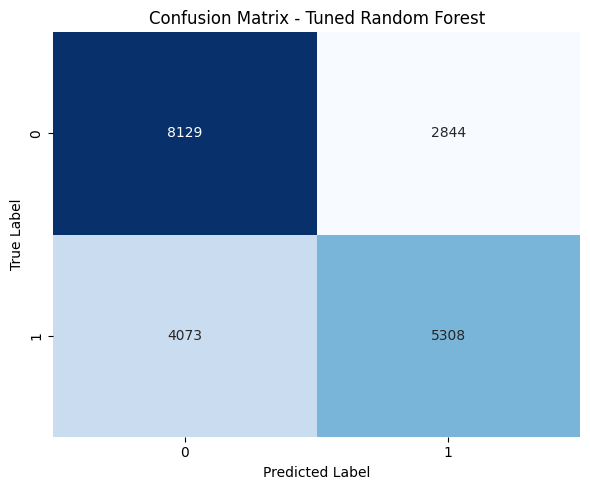

In [8]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix - Tuned Random Forest")

plt.xlabel("Predicted Label")

plt.ylabel("True Label")

plt.tight_layout()

plt.savefig("../images/final_confusion_matrix.png", dpi=300)

plt.show()

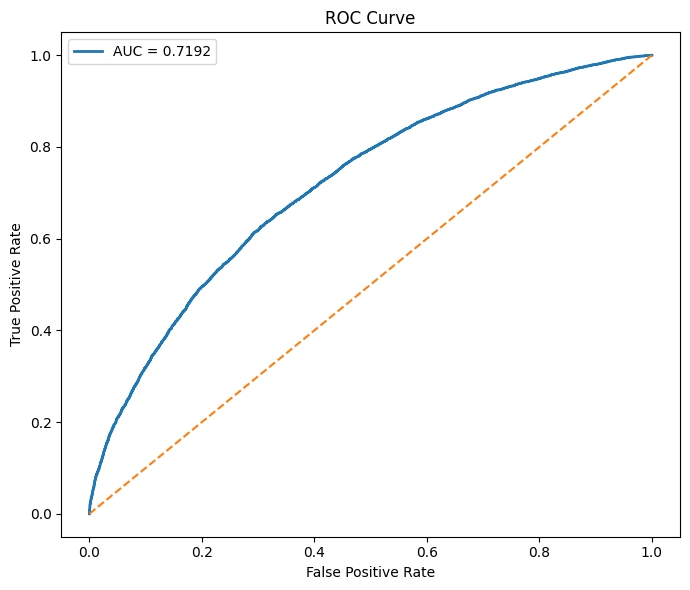

In [9]:
y_prob = model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)

auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {auc_score:.4f}",
    linewidth=2
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.tight_layout()

plt.savefig("../images/roc_curve.png", dpi=300)

plt.show()

In [10]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
0,encounter_id,0.109857
1,patient_nbr,0.108828
16,total_visits,0.072783
17,total_procedures,0.066671
7,num_lab_procedures,0.066197
9,num_medications,0.061199
12,number_inpatient,0.056528
4,discharge_disposition_id,0.047002
2,age,0.042136
6,time_in_hospital,0.041446


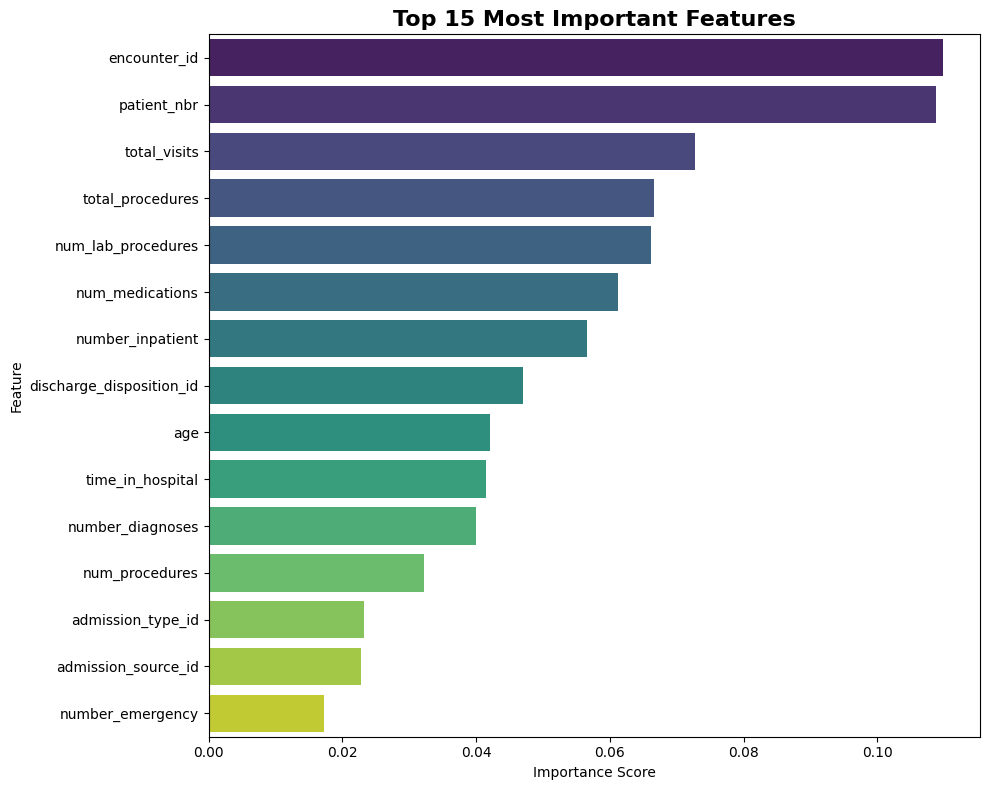

In [11]:
plt.figure(figsize=(10,8))

sns.barplot(
    data=feature_importance.head(15),
    x="Importance",
    y="Feature",
    hue="Feature",
    palette="viridis",
    legend=False
)

plt.title(
    "Top 15 Most Important Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Importance Score")

plt.ylabel("Feature")

plt.tight_layout()

plt.savefig("../images/feature_importance.png", dpi=300)

plt.show()

In [12]:
summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        auc_score
    ]
})

summary = summary.round(4)

summary

,Metric,Score
0,Accuracy,0.6602
1,Precision,0.6511
2,Recall,0.5658
3,F1 Score,0.6055
4,ROC-AUC,0.7192


In [13]:
summary.to_csv(
    "../reports/final_model_results.csv",
    index=False
)

feature_importance.to_csv(
    "../reports/feature_importance.csv",
    index=False
)

print("Final reports saved successfully.")

Final reports saved successfully.
